# Interference Sweep

> Sweep a single parameter to examine its effect on film recall in the selective interference paradigm.

The selective interference paradigm encodes film items, then break items (modeling a retention interval), a reminder that reinstates film context, interference items, and filler items before free recall.
This notebook sweeps one parameter at a time — either a scale factor that modulates encoding/retrieval rates, or the number of items in a phase — and produces a two-panel figure: serial position curves (left) and mean film items recalled with 95% CI (right).
Override the parameters cell via papermill to target different sweeps.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from jax import random
import os
from IPython.display import Markdown

from jaxcmr.analyses.spc import fixed_pres_spc
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.selective_interference import (
    Paradigm,
    add_filler_boundary,
    compute_n_presented,
    film_recalled_stats,
    light_to_dark_colors,
    load_or_fit_params,
    make_factory,
    make_is_emotional,
    plot_interference_spc,
    plot_summary_dv,
    prepare_sweep,
    run_count_sweep,
    run_sweep,
    standard_remap,
    break_extended_remap,
    interference_extended_remap,
    filler_extended_remap,
)

def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    base = os.path.join(figure_dir, f"{figure_str}{suffix_str}")
    plt.savefig(f"{base}.png", bbox_inches="tight", dpi=600)
    plt.savefig(f"{base}.svg", bbox_inches="tight")
    plt.show()

warnings.filterwarnings("ignore")

In [2]:
# --- sweep configuration ---
SWEEP_TITLE = "SPC by Interference MCF Scale"
SWEEP_MODE = "scale"          # "scale" or "count"
SWEEP_PARAM = "interference_mcf_scale"
SWEEP_VALUES = [0.0, 0.33, 0.67, 1.0, 1.33, 1.67, 2.0, 2.33, 2.67, 3.0]
SWEEP_XLABEL = "Interference MCF Scale"
SWEEP_LABEL_FMT = "{:.2f}"
SWEEP_MOTIVATION = ""

# --- paradigm geometry ---
N_FILM = 16
N_BREAK = 0
N_INTERFERENCE = 16
N_FILLER = 16
N_BREAK_MAX = 32
N_INTERFERENCE_MAX = 32
N_FILLER_MAX = 32
EXPERIMENT_COUNT = 100
SHOW_BREAK_IN_SPC = False
SHOW_FILLERS_IN_SPC = True

# --- emotional mechanism ---
FILM_EMOTIONAL = False
INTERFERENCE_EMOTIONAL = False

# --- cache strategy ---
# For scale sweeps only (count sweeps derive this automatically).
# The model is encoded through the chosen phase boundary before
# the sweep begins; phases after the boundary are re-run per
# sweep value.  Set this to the latest phase whose parameters
# are NOT being swept:
#   "creation"      — for sweeping film-phase or encoding params
#   "film"          — for sweeping break params (break_drift_scale,
#                     break_mcf_scale)
#   "break"         — for sweeping reminder params (reminder_drift_scale,
#                     reminder_start_drift_scale)
#   "reminder"      — default; sweeps interference/filler/retrieval params
#   "interference"  — for sweeping filler params only
#   "filler"        — all phases pre-cached; only retrieval varies
CACHE_AFTER = "reminder"

# --- pre-cache scale factors (applied before caching) ---
PRE_CACHE_SCALES = {
    "break_drift_scale": 1.0,
    "break_mcf_scale": 1.0,
    "reminder_start_drift_scale": 4.0,
    "reminder_drift_scale": 0.3,
}

# --- fixed in-sweep scale factors (held constant during scale sweeps) ---
FIXED_SCALES = {
    "filler_drift_scale": 1.0,
    "filler_mcf_scale": 1.0,
}

# --- fitting ---
SEED = 0
DATA_TAG = "HealeyKahana2014"
DATA_PATH = "data/HealeyKahana2014.h5"
TRIAL_QUERY = "data['listtype'] == -1"
MODEL_NAME = "WeirdCMRPosStop"
BEST_OF = 3
RUN_TAG = "fixed_term_best_of_3"
REDO_FITS = False
PARAM_SCALES = {"stop_probability_scale": 0.57}
FIT_DIR = "projects/selective_interference/simulations/fits"
FIGURE_DIR = ""
FIGURE_STR = ""

In [3]:
# Parameters
N_FILM = 16
N_BREAK = 16
N_INTERFERENCE = 16
N_FILLER = 16
N_BREAK_MAX = 32
N_INTERFERENCE_MAX = 32
N_FILLER_MAX = 32
EXPERIMENT_COUNT = 100
SHOW_BREAK_IN_SPC = False
SHOW_FILLERS_IN_SPC = False
SEED = 0
DATA_TAG = "HealeyKahana2014"
DATA_PATH = "data/HealeyKahana2014.h5"
MODEL_NAME = "WeirdCMRPosStop"
BEST_OF = 3
RUN_TAG = "fixed_term_best_of_3"
REDO_FITS = False
PARAM_SCALES = {"stop_probability_scale": 0.57}
FIT_DIR = "projects/selective_interference/simulations/fits"
SWEEP_TITLE = "SPC by Start Drift Scale"
SWEEP_MODE = "scale"
SWEEP_PARAM = "start_drift_scale"
SWEEP_VALUES = [0.2, 0.5111111111111111, 0.8222222222222222, 1.1333333333333333, 1.4444444444444444, 1.7555555555555555, 2.066666666666667, 2.377777777777778, 2.688888888888889, 3.0]
SWEEP_XLABEL = "Start Drift Scale"
SWEEP_MOTIVATION = "At retrieval, context reinstates toward start-of-list via `start_drift_rate`. Scaling this modulates how far context moves toward the beginning before free recall begins, affecting which items are most accessible."
FIGURE_DIR = "/Users/jordangunn/jaxcmr/projects/selective_interference/simulations/figures"
FIGURE_STR = "retrieval_start_drift_scale"


In [4]:
#| output: asis
if SWEEP_MOTIVATION:
    display(Markdown(SWEEP_MOTIVATION))

At retrieval, context reinstates toward start-of-list via `start_drift_rate`. Scaling this modulates how far context moves toward the beginning before free recall begins, affecting which items are most accessible.

In [5]:
# --- derive tier and cache_after for count sweeps ---
_COUNT_TIER = {
    "n_break": "break_extended",
    "n_interference": "interference_extended",
    "n_filler": "filler_extended",
}
_COUNT_CACHE = {
    "n_break": "film",
    "n_interference": "reminder",
    "n_filler": "reminder",
}
if SWEEP_MODE == "count":
    _tier = _COUNT_TIER[SWEEP_PARAM]
    _cache_after = _COUNT_CACHE[SWEEP_PARAM]
else:
    _tier = "standard"
    _cache_after = CACHE_AFTER

paradigm = Paradigm(
    n_film=N_FILM,
    n_break=N_BREAK,
    n_interference=N_INTERFERENCE,
    n_filler=N_FILLER,
    n_break_max=N_BREAK_MAX,
    n_interference_max=N_INTERFERENCE_MAX,
    n_filler_max=N_FILLER_MAX,
    experiment_count=EXPERIMENT_COUNT,
)

project_root = Path(find_project_root())
fit_dir = project_root / FIT_DIR
fit_dir.mkdir(parents=True, exist_ok=True)
fit_path = fit_dir / f"{DATA_TAG}_{MODEL_NAME}_{RUN_TAG}.json"

data = load_data(str(project_root / DATA_PATH))
trial_mask = generate_trial_mask(data, TRIAL_QUERY)
is_emotional = make_is_emotional(paradigm, FILM_EMOTIONAL, INTERFERENCE_EMOTIONAL)
factory = make_factory(is_emotional=is_emotional)
rng = random.PRNGKey(SEED)

params, n_subjects = load_or_fit_params(
    fit_path,
    param_scales=PARAM_SCALES,
    data=data,
    trial_mask=trial_mask,
    model_factory=factory,
    redo_fits=REDO_FITS,
    best_of=BEST_OF,
)

prep = prepare_sweep(
    params, paradigm, factory,
    cache_after=_cache_after, tier=_tier,
    **PRE_CACHE_SCALES,
)
print(f"{n_subjects} subjects, tier={_tier}, cache_after={_cache_after}")

Loaded fits from /Users/jordangunn/jaxcmr/projects/selective_interference/simulations/fits/HealeyKahana2014_WeirdCMRPosStop_fixed_term_best_of_3.json
  Scaled stop_probability_scale by 0.57


126 subjects, tier=standard, cache_after=reminder


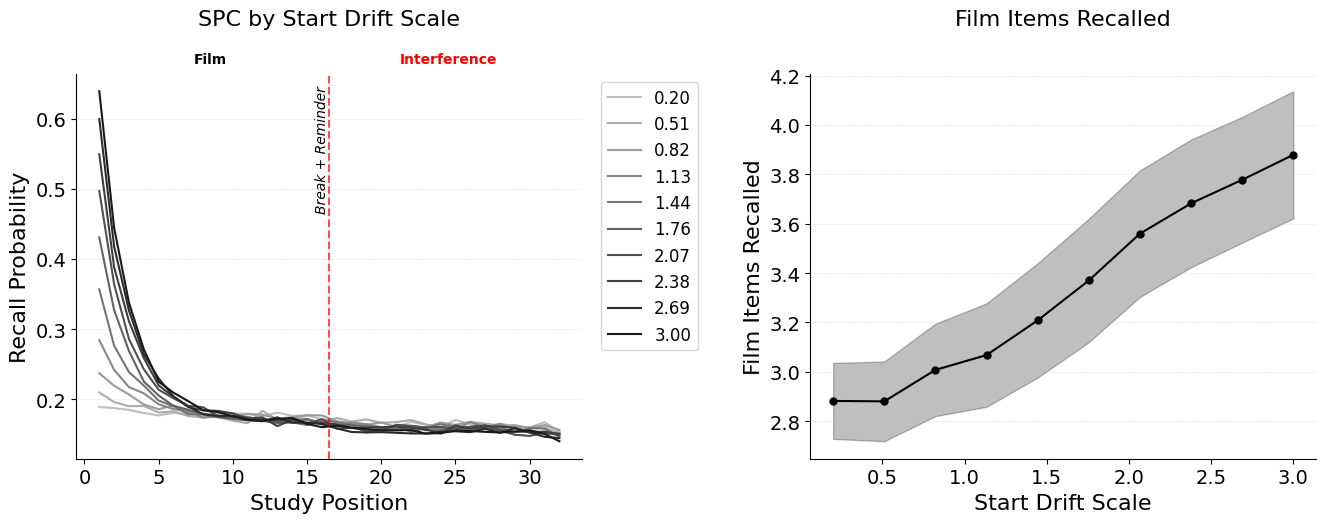

In [6]:
sweep_values = np.array(SWEEP_VALUES)

# --- run sweep ---
if SWEEP_MODE == "scale":
    recalls_4d, rng = run_sweep(
        prep, rng, **{SWEEP_PARAM: sweep_values, **FIXED_SCALES},
    )
else:
    recalls_4d, rng = run_count_sweep(
        prep, rng, paradigm, SWEEP_PARAM, [int(v) for v in sweep_values],
    )

# --- remap + SPC + stats ---
_remap_fn = {
    "standard": standard_remap,
    "break_extended": break_extended_remap,
    "interference_extended": interference_extended_remap,
    "filler_extended": filler_extended_remap,
}[_tier]

_remap_kw = {}
if _tier == "break_extended":
    _remap_kw["n_break"] = paradigm.n_break_max
elif _tier == "interference_extended":
    _remap_kw["n_interference"] = paradigm.n_interference_max

# For count sweeps the remap always uses max slots, so compute SPC
# and plot mask at the max n_presented.  Unused positions show as
# NaN via the arr[arr == 0.0] = np.nan guard in plot_interference_spc.
if SWEEP_MODE == "count":
    _max_kw = {SWEEP_PARAM: int(max(sweep_values))}
    if _tier == "break_extended":
        _max_kw["n_break"] = paradigm.n_break_max
    elif _tier == "interference_extended":
        _max_kw["n_interference"] = paradigm.n_interference_max
    elif _tier == "filler_extended":
        _max_kw["n_filler"] = paradigm.n_filler_max
    n_presented = compute_n_presented(
        paradigm,
        show_break=SHOW_BREAK_IN_SPC,
        show_fillers=SHOW_FILLERS_IN_SPC,
        **_max_kw,
    )
else:
    n_presented = compute_n_presented(
        paradigm,
        show_break=SHOW_BREAK_IN_SPC,
        show_fillers=SHOW_FILLERS_IN_SPC,
    )

spcs, stats = [], []
for i in range(recalls_4d.shape[0]):
    recalls = recalls_4d[i].reshape(-1, recalls_4d.shape[-1])
    recalls = _remap_fn(recalls, paradigm, **_remap_kw)
    spcs.append(fixed_pres_spc(recalls, n_presented))
    stats.append(film_recalled_stats(recalls, paradigm, n_subjects))

# --- summary stats ---
# Effective zone widths for boundary placement (match remap output)
_n_break_plot = paradigm.n_break_max if _tier == "break_extended" else N_BREAK
_n_interf_plot = paradigm.n_interference_max if _tier == "interference_extended" else N_INTERFERENCE
_n_filler_plot = paradigm.n_filler_max if _tier == "filler_extended" else N_FILLER

n_break_shown = _n_break_plot if SHOW_BREAK_IN_SPC else 0
labels = [SWEEP_LABEL_FMT.format(v) for v in sweep_values]
colors = light_to_dark_colors(len(spcs))
means, ci_lo, ci_hi = zip(*stats)

if FIGURE_DIR and FIGURE_STR:
    import csv
    os.makedirs(FIGURE_DIR, exist_ok=True)
    csv_path = os.path.join(FIGURE_DIR, f"{FIGURE_STR}.csv")
    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["value", "mean", "ci_lower", "ci_upper"])
        for v, m, lo, hi in zip(sweep_values, means, ci_lo, ci_hi):
            writer.writerow([v, m, lo, hi])

    # SPC sidecar
    spc_csv_path = os.path.join(FIGURE_DIR, f"{FIGURE_STR}_spc.csv")
    with open(spc_csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["value", "position", "phase", "recall_prob"])
        for val, spc in zip(sweep_values, spcs):
            arr = np.asarray(spc, dtype=float)
            for pos_idx in range(len(arr)):
                pos = pos_idx + 1
                if pos <= N_FILM:
                    phase = "film"
                elif pos <= N_FILM + n_break_shown:
                    phase = "break"
                elif pos <= N_FILM + n_break_shown + _n_interf_plot:
                    phase = "interference"
                else:
                    phase = "filler"
                writer.writerow([val, pos, phase, arr[pos_idx]])

# --- plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"wspace": 0.45})
plot_interference_spc(
    spcs, labels, n_film=N_FILM, n_break=n_break_shown,
    n_presented=n_presented, color_cycle=colors, axis=axes[0],
)
if SHOW_FILLERS_IN_SPC and _n_filler_plot > 0:
    add_filler_boundary(
        axes[0], N_FILM, _n_interf_plot, _n_filler_plot, n_presented,
        n_break=n_break_shown, show_fillers=True,
    )
axes[0].set_title(SWEEP_TITLE, fontsize=16, pad=35)
axes[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=12)

plot_summary_dv(sweep_values.tolist(), means, ci_lo, ci_hi, xlabel=SWEEP_XLABEL, axis=axes[1])
axes[1].set_title("Film Items Recalled", fontsize=16, pad=35)
save_figure(FIGURE_DIR, FIGURE_STR)